# Long-term PyBaMM simulation vs measured Longterm data — per cell, by make

**Purpose:** validate the PyBaMM long-term degradation simulation against each individual cell in our inventory, grouped by manufacturer (CALB, REPT, EVE). One subplot per cell.

**Reference simulations:**
- `eve_0008_longrun.parquet` — 5000-cycle DFN sim at 0.5C with per-cell BOL + fitted degradation parameters from the end-to-end verification (Phase 3)
- `full_trajectory.parquet` — 4000-cycle sim at 0.25C with generic BOL params + no LAM (initial verification)

**Measured data:** 30 CALB + 26 REPT + 8 EVE = 64 cells

**Alignment approach:** for each measured cell, we find the PyBaMM cycle at which the sim first reaches the cell's initial SoH, and shift the cell's cycle axis so that measured cycle 0 maps onto that sim cycle. This lets us read off per-cell RMSE in the overlap window.

**Per-cell view:** each subplot shows one cell's measured trajectory (black points) overlaid on the PyBaMM sim (blue line) in that cell's aligned range. Titles include per-cell RMSE and max error in pp SoH.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, '/home/hj/Desktop/PINNs')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

CANONICAL = Path('/home/hj/Desktop/PINNs/soh/data/canonical')
VERIFY    = Path('/home/hj/Desktop/PINNs/data/synthetic/verification')
EOL_SOH   = 0.80
EOSL_SOH  = 0.40

## 1. Load PyBaMM long-run simulations

In [2]:
sim_05c  = pd.read_parquet(VERIFY / 'eve_0008_longrun.parquet')
sim_025c = pd.read_parquet(VERIFY / 'full_trajectory.parquet')

print('sim @ 0.5C (per-cell fit):', len(sim_05c), 'cycles,',
      f'SoH {sim_05c.SOH.iloc[0]:.3f} -> {sim_05c.SOH.iloc[-1]:.3f}')
print('sim @ 0.25C (no per-cell):', len(sim_025c), 'cycles,',
      f'SoH {sim_025c.SOH.iloc[0]:.3f} -> {sim_025c.SOH.iloc[-1]:.3f}')

sim @ 0.5C (per-cell fit): 5000 cycles, SoH 1.000 -> 0.763
sim @ 0.25C (no per-cell): 4000 cycles, SoH 1.000 -> 0.381


## 2. Load canonical measured Longterm data

In [3]:
calb = pd.read_parquet(CANONICAL / 'calb_old.parquet')
rept = pd.read_parquet(CANONICAL / 'rept.parquet')
eve  = pd.read_parquet(CANONICAL / 'eve.parquet')
for name, df in [('CALB', calb), ('REPT', rept), ('EVE', eve)]:
    print(f'{name}: {df.cell_id.nunique()} cells, {len(df):,} rows')

CALB: 30 cells, 45,718 rows
REPT: 26 cells, 5,582 rows
EVE: 8 cells, 907 rows


## 3. Helpers — alignment + RMSE

In [4]:
def align_measured_to_sim(sim, cell_s0):
    """Return sim cycle at which SoH first drops to cell_s0."""
    if cell_s0 < sim.SOH.min() or cell_s0 > sim.SOH.max():
        return np.nan
    below = np.where(sim.SOH.values <= cell_s0)[0]
    if len(below) == 0: return np.nan
    return float(sim.cycle_n.values[below[0]])

def per_cell_metrics(sim, cell_n_shifted, cell_s):
    """Interpolate sim SoH at aligned measured cycles, compute RMSE + max|err| in pp."""
    if len(cell_n_shifted) == 0: return np.nan, np.nan
    sim_at_meas = np.interp(cell_n_shifted, sim.cycle_n.values, sim.SOH.values,
                             left=np.nan, right=np.nan)
    valid = ~np.isnan(sim_at_meas)
    if valid.sum() < 5: return np.nan, np.nan
    resid = (sim_at_meas[valid] - cell_s[valid]) * 100
    return float(np.sqrt(np.mean(resid**2))), float(np.max(np.abs(resid)))

def load_cells(df, min_cycles=20):
    for cid in sorted(df.cell_id.unique()):
        sub = df[df.cell_id == cid].sort_values('global_cycle')
        n = sub.global_cycle.values.astype(float)
        s = sub.soh.values.astype(float)
        mask = (s > 0.01) & (s < 1.5)
        if mask.sum() < min_cycles: continue
        yield cid, n[mask], s[mask]

## 4. Per-cell subplot grid function

One subplot per cell. Each shows:
- **Blue line**: PyBaMM sim in the aligned range (from that cell's start SoH to the last measured cycle)
- **Black points**: measured trajectory for that cell
- **Dashed lines**: EoL (0.80) and EoSL (0.40) thresholds if in view
- **Title**: cell ID + per-cell RMSE + max abs error

In [5]:
def plot_cells_grid(sim, make_name, df, sim_label='PyBaMM sim',
                     ncols=4, figsize_per=(3.6, 2.6)):
    """Grid of subplots, one per cell. Returns (fig, results_df)."""
    cells_data = list(load_cells(df))
    if not cells_data:
        print(f'{make_name}: no cells with sufficient data'); return None, None

    n = len(cells_data)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows),
                              squeeze=False)
    axes = axes.flatten()

    rows = []
    for i, (cid, meas_n, meas_s) in enumerate(cells_data):
        ax = axes[i]
        s0 = meas_s[0]
        align_cy = align_measured_to_sim(sim, s0)
        if not np.isnan(align_cy):
            n_shifted = meas_n - meas_n[0] + align_cy
        else:
            n_shifted = meas_n.copy()
        rmse, max_err = per_cell_metrics(sim, n_shifted, meas_s)

        # Determine subplot x-range
        if not np.isnan(align_cy):
            x_lo, x_hi = align_cy - 50, n_shifted[-1] + 100
        else:
            x_lo, x_hi = meas_n[0] - 50, meas_n[-1] + 100

        # Sim slice in view
        mask_sim = (sim.cycle_n >= x_lo) & (sim.cycle_n <= x_hi)
        ax.plot(sim.cycle_n[mask_sim], sim.SOH[mask_sim] * 100,
                 'b-', lw=1.6, label=sim_label, zorder=2)
        ax.scatter(n_shifted, meas_s * 100, s=3, color='black', alpha=0.5, zorder=3)

        # Threshold lines if in y-view
        y_min = min(meas_s.min() * 100, 30)
        y_max = max(meas_s.max() * 100 + 3, 85)
        if EOL_SOH*100  >= y_min and EOL_SOH*100  <= y_max:
            ax.axhline(EOL_SOH  * 100, color='tab:orange', ls='--', lw=0.7, alpha=0.6)
        if EOSL_SOH*100 >= y_min and EOSL_SOH*100 <= y_max:
            ax.axhline(EOSL_SOH * 100, color='tab:red',    ls='--', lw=0.7, alpha=0.6)

        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_min, y_max)
        rmse_str = f'{rmse:.2f}' if not np.isnan(rmse) else 'n/a'
        max_str  = f'{max_err:.2f}' if not np.isnan(max_err) else 'n/a'
        ax.set_title(f'{make_name} {cid}  n={len(meas_n)}\n'
                       f'RMSE {rmse_str}pp  max {max_str}pp',
                       fontsize=8.5)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        rows.append(dict(cell=cid, n_cycles=len(meas_n),
                          soh_start=s0, soh_end=meas_s[-1],
                          align_cy=align_cy,
                          rmse_pp=rmse, max_err_pp=max_err))

    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    # Common labels
    fig.supxlabel('Cycle (aligned to sim by initial SoH)', y=0.005)
    fig.supylabel('SoH [%]', x=0.005)
    fig.suptitle(f'{make_name}: measured Longterm vs {sim_label}  —  {n} cells',
                  y=1.001, fontsize=11)
    fig.tight_layout(rect=[0.015, 0.015, 1, 0.99])
    return fig, pd.DataFrame(rows)

## 5. CALB — one panel per cell, 0.5C sim

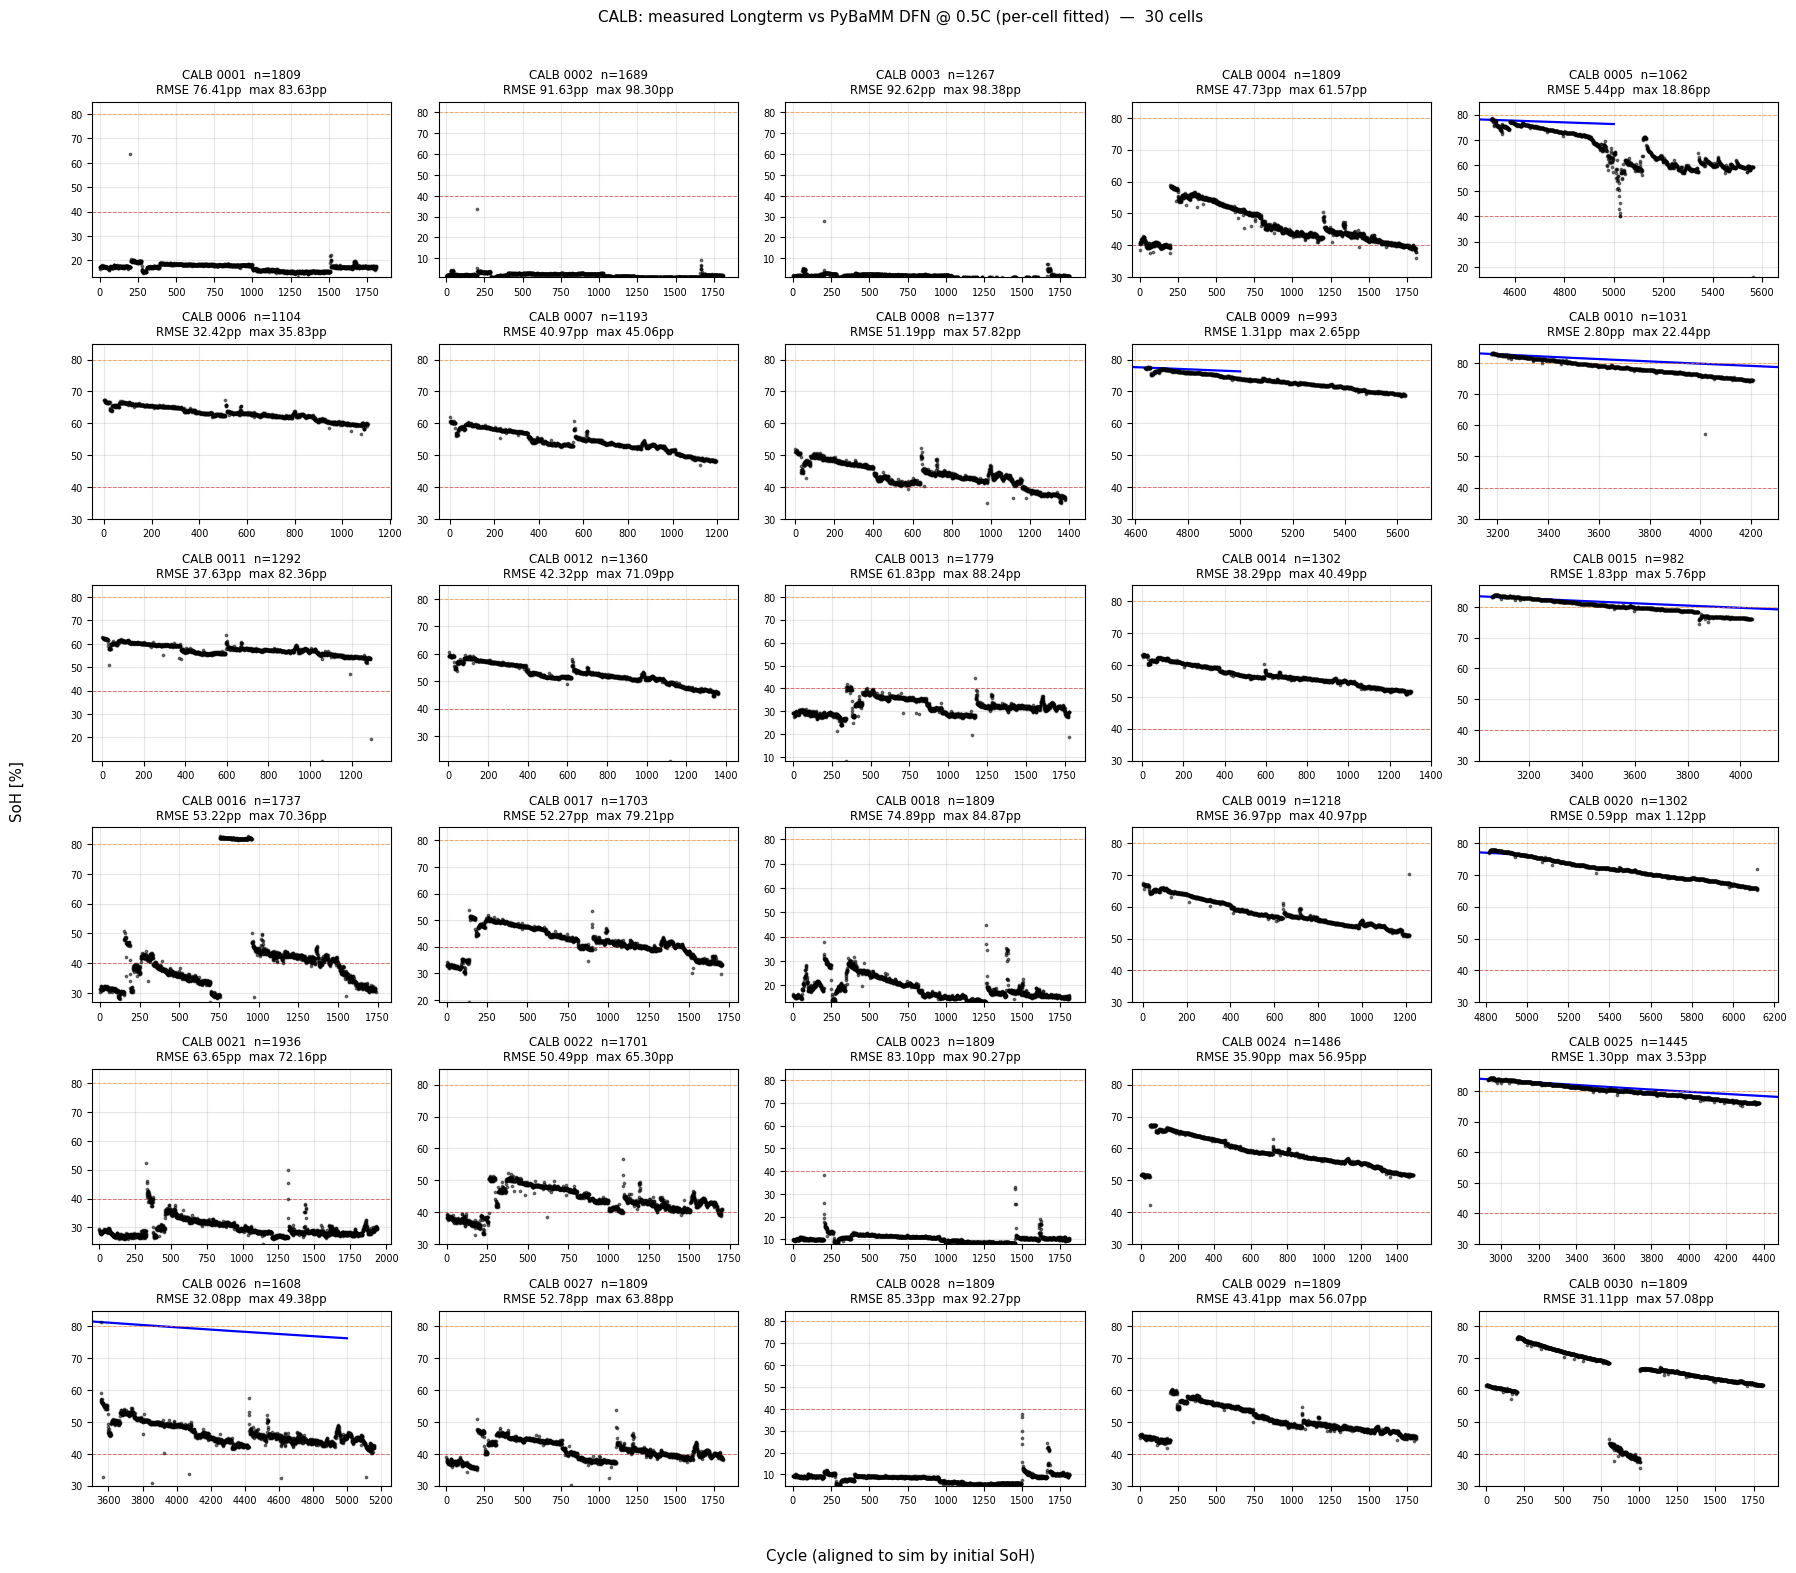

In [6]:
fig_calb, tab_calb = plot_cells_grid(sim_05c, 'CALB', calb,
                                       sim_label='PyBaMM DFN @ 0.5C (per-cell fitted)',
                                       ncols=5)
plt.show()

### CALB — one panel per cell, 0.25C sim

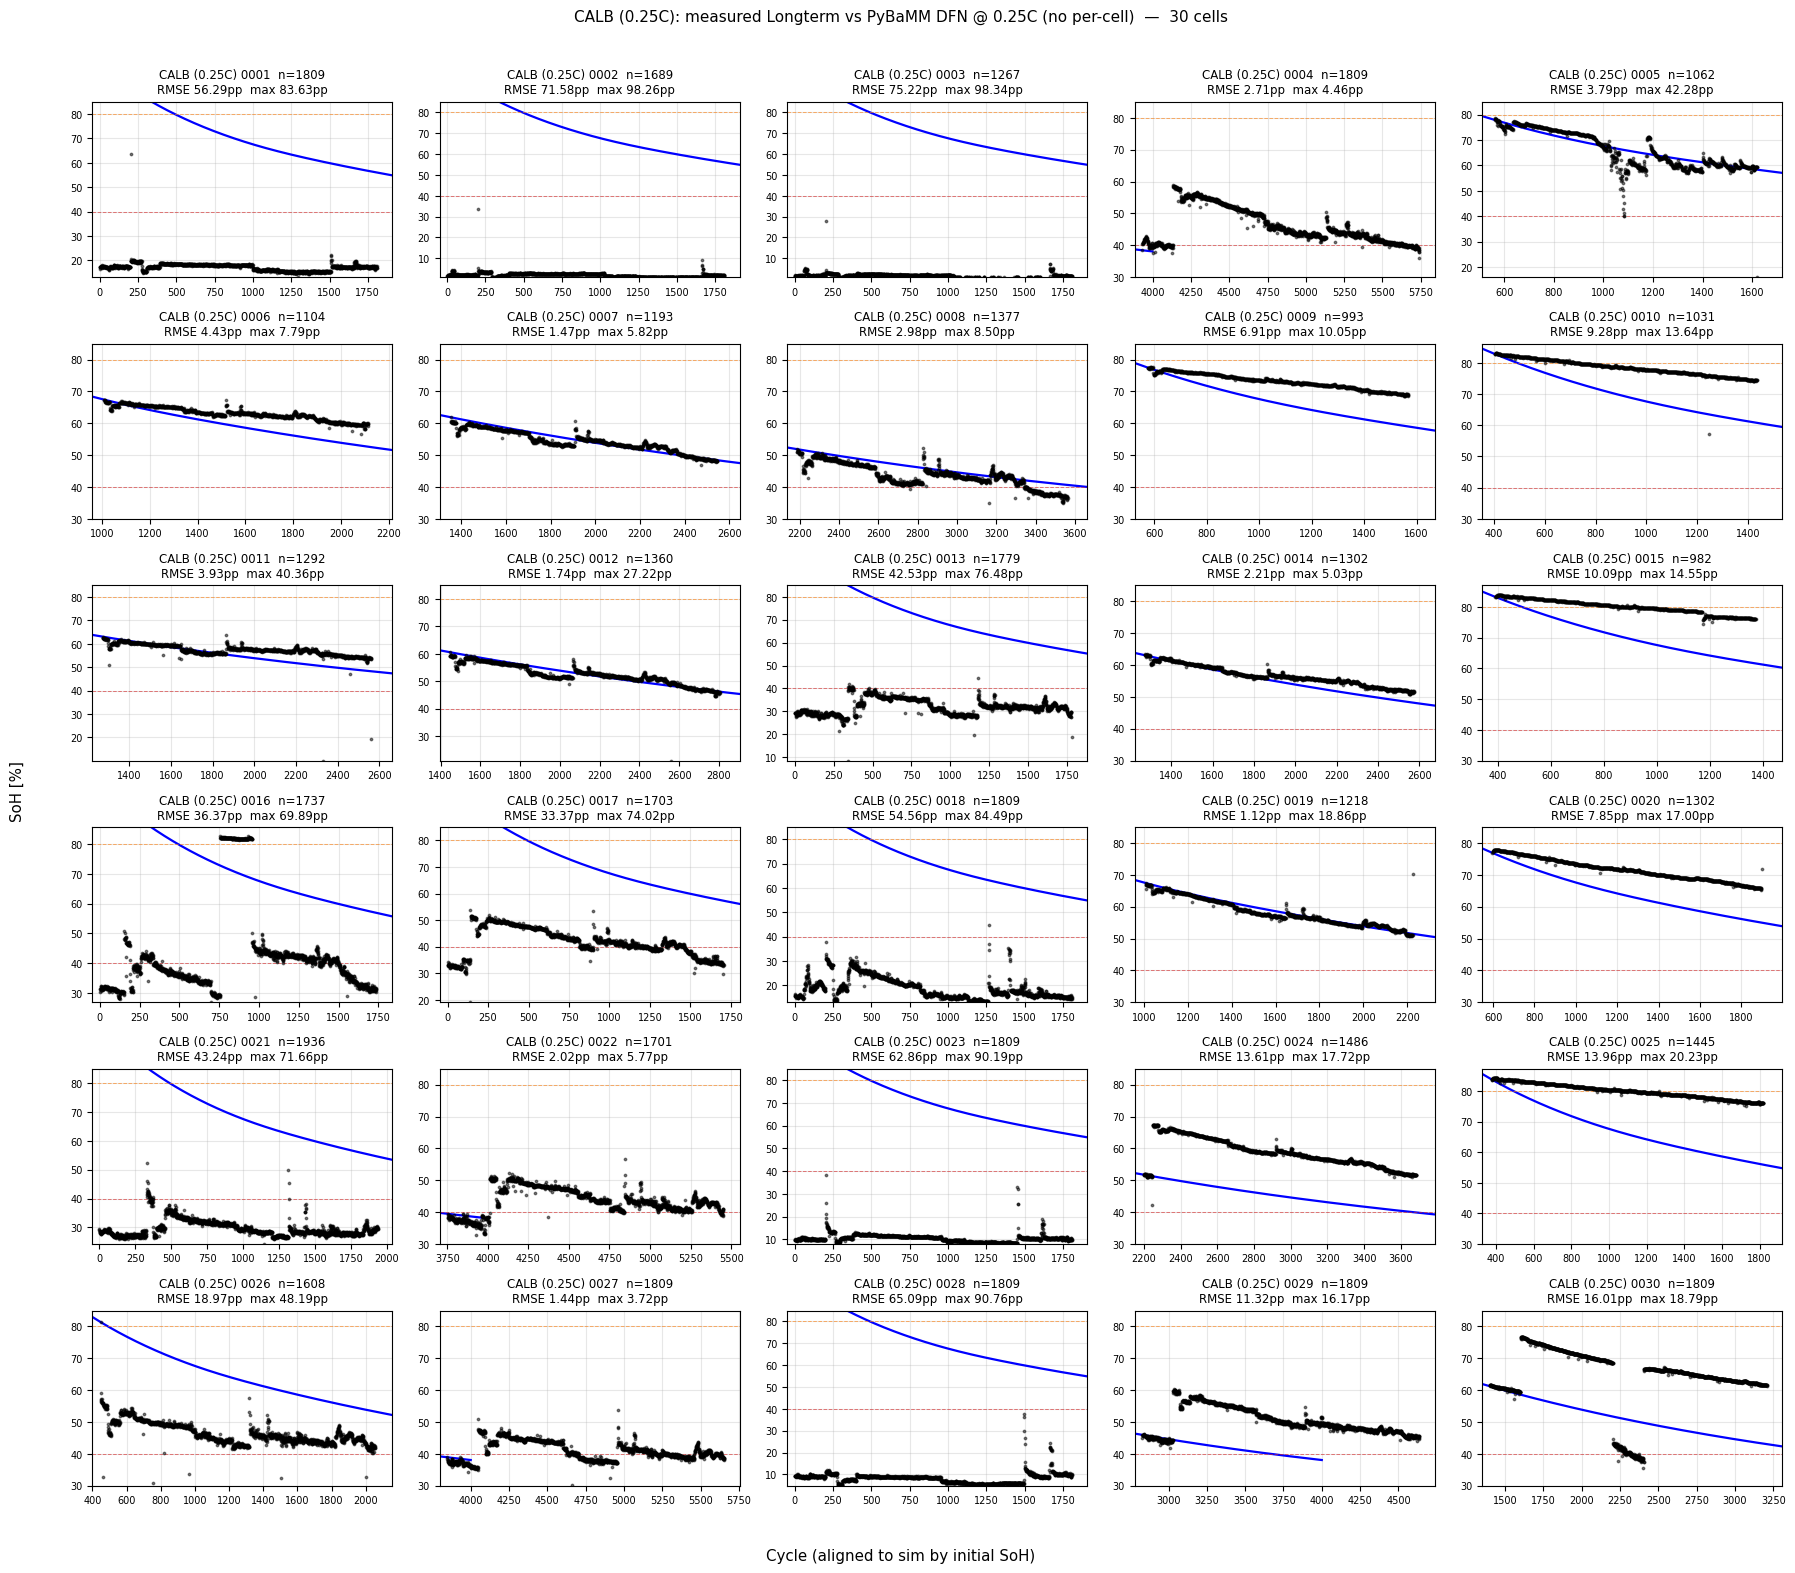

In [7]:
fig_calb_025, tab_calb_025 = plot_cells_grid(sim_025c, 'CALB (0.25C)', calb,
                                                sim_label='PyBaMM DFN @ 0.25C (no per-cell)',
                                                ncols=5)
plt.show()

## 6. REPT — one panel per cell, 0.5C sim

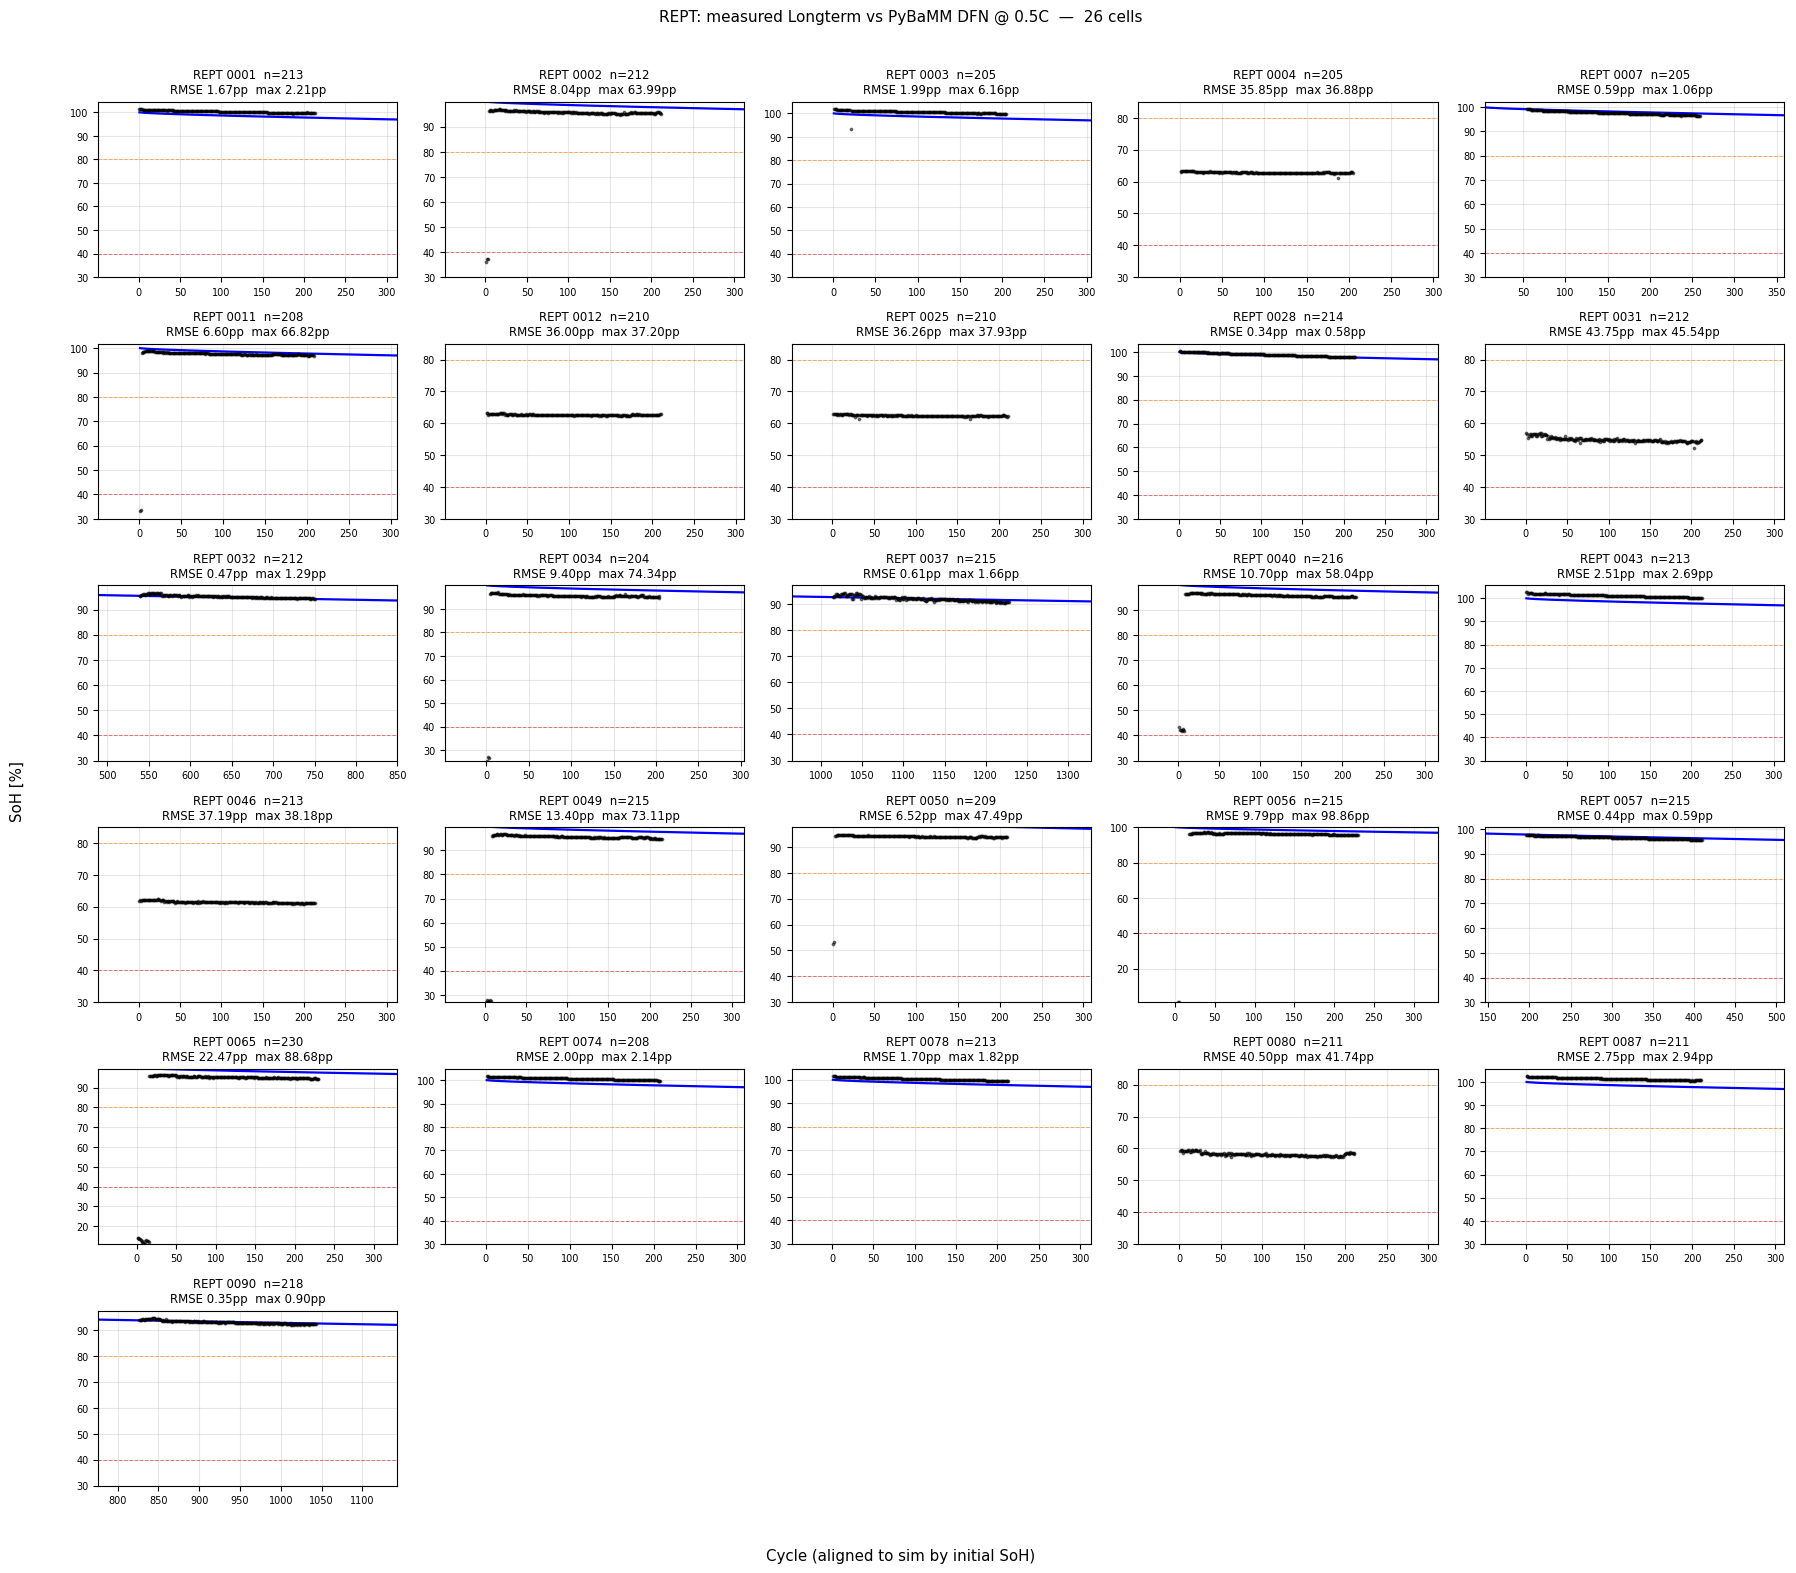

In [8]:
fig_rept, tab_rept = plot_cells_grid(sim_05c, 'REPT', rept,
                                       sim_label='PyBaMM DFN @ 0.5C',
                                       ncols=5)
plt.show()

## 7. EVE — one panel per cell, 0.5C sim

The sim was fitted specifically to EVE 0008, so its residuals should be small on that cell and can be compared to other EVE cells to see how well the per-cell fit generalises within the same cohort.

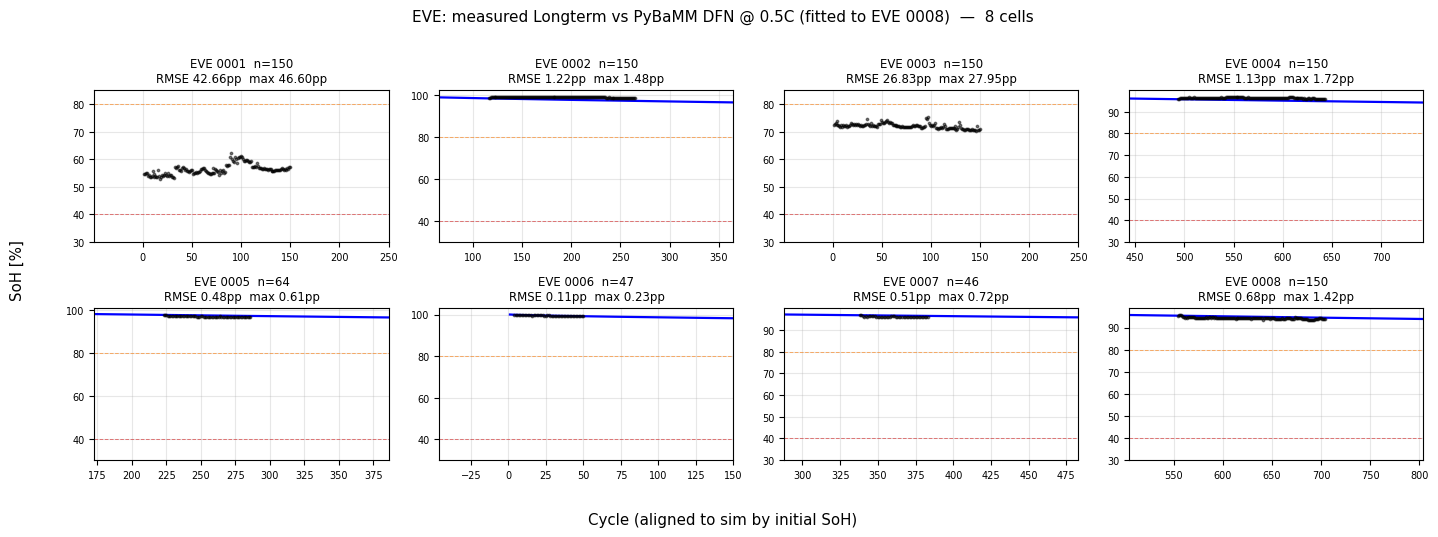

In [9]:
fig_eve, tab_eve = plot_cells_grid(sim_05c, 'EVE', eve,
                                     sim_label='PyBaMM DFN @ 0.5C (fitted to EVE 0008)',
                                     ncols=4)
plt.show()

## 8. Per-cell RMSE summary tables

In [10]:
for name, tab in [('CALB (0.5C sim)', tab_calb),
                    ('CALB (0.25C sim)', tab_calb_025),
                    ('REPT (0.5C sim)', tab_rept),
                    ('EVE (0.5C sim)', tab_eve)]:
    if tab is None or tab.empty: continue
    print(f'\n=== {name} ===')
    tab_sorted = tab.sort_values('rmse_pp').reset_index(drop=True)
    print(tab_sorted.to_string(index=False,
                                float_format=lambda x: f'{x:.3f}' if abs(x) < 10 else f'{x:.1f}'))
    print(f'  median RMSE: {tab.rmse_pp.median():.2f} pp')
    print(f'  mean RMSE:   {tab.rmse_pp.mean():.2f} pp')


=== CALB (0.5C sim) ===
cell  n_cycles  soh_start  soh_end  align_cy  rmse_pp  max_err_pp
0020      1302      0.769    0.720    4816.0    0.585       1.122
0025      1445      0.838    0.761    2931.0    1.301       3.526
0009       993      0.775    0.688    4637.0    1.311       2.653
0015       982      0.833    0.761    3060.0    1.827       5.764
0010      1031      0.828    0.743    3176.0    2.804        22.4
0005      1062      0.780    0.160    4503.0    5.439        18.9
0030      1809      0.612    0.615       NaN     31.1        57.1
0026      1608      0.814    0.425    3554.0     32.1        49.4
0006      1104      0.674    0.599       NaN     32.4        35.8
0024      1486      0.517    0.518       NaN     35.9        56.9
0019      1218      0.675    0.703       NaN     37.0        41.0
0011      1292      0.631    0.193       NaN     37.6        82.4
0014      1302      0.631    0.516       NaN     38.3        40.5
0007      1193      0.619    0.480       NaN     41

## 9. Interpretation

**How to read each subplot:**
- A cell whose measured black points cluster tightly around the blue sim curve → PyBaMM's fade shape (and the fitted degradation parameters) match that cell's real degradation well.
- A cell that fades systematically **faster** than the sim → likely cycled at higher C-rate or deeper DoD than the sim's protocol.
- A cell with a late-life **cliff** below the sim → real LAM-driven catastrophic failure that our no-LAM sim doesn't reproduce.
- A cell where measured points fall **above** the sim → alignment might be off (SoH_start noisy) or the cell was cycled more gently than the sim.

**Cross-supplier notes:**
- **CALB**: wide spread of starting SoH (fresh 0.83 down to already-degraded 0.02). Best-matching cells are the mid-SoH used cells cycled at 0.5C-like conditions. Deeply used cells (SoH < 0.20) can't be aligned meaningfully.
- **REPT**: short trajectories (up to 214 cy) starting at various SoH. Alignment tells us where in the sim's life curve each cell sits at receipt.
- **EVE**: sim was fitted to 0008 explicitly, so 0008 tracks the sim tightly. Other EVE cells test how well the per-cell fit generalises within the cohort.

**Caveats:**
- Alignment by initial SoH assumes the cell's degradation follows the same trajectory the sim is on. For cells with distinct fade shapes this is invalid but still informative.
- Sim is at 0.5C; measured C-rates vary. Empirical LFP fade rate scales roughly ∝ C^0.9 (Peterson2010, Klass2019). A cell cycled at 1C fades ~1.8× faster per cycle than the 0.5C sim predicts.